# Unit 8 Artefact 3: A Quantitative Model of Supplier Impersonation Fraud at Pampered Pets

Ian Stevens, Security and Risk Management, Unit 8.

Our team's STRIDE table for the digitalised business listed spoofing by **phishing emails** against 'email, invoices, supplier trust', with monetary loss as the impact, and rated it medium likelihood and high risk (Group 2, 2025). My executive summary then moved Pampered Pets to an international supply chain (Stevens, 2026). This notebook turns that one qualitative row into a quantitative model of the most direct way it causes a loss: an email that appears to come from a real supplier and asks for future payments to go to a new bank account.

It uses what the Unit 8 reading and Artefact 2 showed:

1. An **absorbing Markov chain** for a single attempt, with states where the attack can actually fail, so that the result is a probability of success and not a measure of speed (Aijaz and Nazir, 2024; Artefact 2, section 3.3).
2. A **two-stage Monte Carlo** in which uncertain inputs are drawn first and outcomes second, so that the spread of results reflects what we do not know (my Unit 7 action plan).
3. **Common random numbers** across the control options, the default in Eckstein and Riedmueller's (2002) YASAI add-in, so that differences between options come from the controls and not from sampling noise.
4. A **sensitivity analysis**, a **Bayesian update** of the input that matters most and a **check against national data**.

**Every input is an assumption** made for this exercise, set out in section 1. The case study gives no figures for supplier payments or email volumes, and the results should be read as a comparison of controls, not as a forecast.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(2026)
pd.set_option("display.width", 140)

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 2,
})
BLUE, ORANGE, AQUA, VIOLET, INK = "#2a78d6", "#eb6834", "#1baf7a", "#7c5cd6", "#52514e"

## 1. The scenario and its inputs

An attacker who has learned the name of one of Pampered Pets' overseas suppliers sends an email that appears to come from that supplier's accounts team. It says the supplier's bank details have changed and asks for the next invoice to be paid into a new account. The principle is **authority**, the most common one in Bullée et al.'s (2018) scenarios and in Aijaz and Nazir's Table 2, and the modality is **email**. If nobody replies, the attacker may send a follow-up.

With four staff, whoever reads the supplier inbox also pays the invoices, so there is no separation of duties to rely on. Each input is a triangular range (minimum, most likely, maximum) of the kind used in my executive summary.

In [2]:
inputs = pd.DataFrame([
    ("lam",  "Convincing supplier-impersonation emails reaching the inbox per year", 0.5, 2.0, 6.0),
    ("e",    "Staff member engages with an email (acts on it or replies)",            0.20, 0.40, 0.60),
    ("r",    "Attacker sends a follow-up after being ignored",                       0.20, 0.40, 0.60),
    ("p",    "Engaged staff member accepts the new bank details (authority)",        0.20, 0.40, 0.60),
    ("v0",   "Change is caught before payment: no formal check",                     0.00, 0.10, 0.30),
    ("v1",   "Change is caught before payment: call-back to a known number",         0.70, 0.90, 0.97),
    ("t",    "Training multiplier on e and p (1 = no effect)",                       0.60, 0.85, 1.05),
    ("loss", "Value of the diverted payment (GBP)",                                  1500, 4000, 15000),
], columns=["name", "description", "min", "mode", "max"]).set_index("name")
inputs

,description,min,mode,max
name,,,,
lam,Convincing supplier-impersonation emails reaching the inbox per year,0.5,2.00,6.00
e,Staff member engages with an email (acts on it or replies),0.2,0.40,0.60
r,Attacker sends a follow-up after being ignored,0.2,0.40,0.60
p,Engaged staff member accepts the new bank details (authority),0.2,0.40,0.60
v0,Change is caught before payment: no formal check,0.0,0.10,0.30
v1,Change is caught before payment: call-back to a known number,0.7,0.90,0.97
t,Training multiplier on e and p (1 = no effect),0.6,0.85,1.05
loss,Value of the diverted payment (GBP),1500.0,4000.00,15000.00


Two inputs need a note. Aijaz and Nazir give email an effectiveness of 0.2 and authority 0.63, but a targeted message that copies a real supplier is more convincing than average phishing, so `e` and `p` are set around 0.4. The training multiplier is allowed to go above 1 because Lain, Kostiainen and Čapkun (2022), in a 15-month study of more than 14,000 employees, found that embedded phishing training did not make staff more resilient and could make them more susceptible. The model therefore does not assume that training works.

## 2. One attempt as an absorbing Markov chain

States: **Delivered** (D), **Engaged** (E) and **Persuaded** (P) are transient; **Paid** (the attacker succeeds) and **Stopped** (ignored for good, refused or caught) are absorbing.

* D → E with probability *e*; D → D with probability (1 − *e*)·*r* (a follow-up arrives); otherwise D → Stopped.
* E → P with probability *p*; otherwise E → Stopped (the staff member spots it).
* P → Paid with probability 1 − *v*; P → Stopped with probability *v* (the change is caught).

The probability of ending in Paid comes from the fundamental matrix *N* = (*I* − *Q*)⁻¹ and *B* = *NR*, where *Q* holds the transitions between transient states and *R* those into absorbing states.

In [3]:
def chain(e, r, p, v):
    Q = np.array([[(1 - e) * r, e, 0],        # Delivered
                  [0, 0, p],                  # Engaged
                  [0, 0, 0]])                 # Persuaded
    R = np.array([[0, (1 - e) * (1 - r)],     # columns: Paid, Stopped
                  [0, 1 - p],
                  [1 - v, v]])
    return Q, R

def absorption(e, r, p, v):
    Q, R = chain(e, r, p, v)
    N = np.linalg.inv(np.eye(3) - Q)
    return N @ R, N

modes = inputs["mode"]
B, N = absorption(modes.e, modes.r, modes.p, modes.v0)
print("Absorption probabilities from each start state (most likely inputs, no formal check):")
print(pd.DataFrame(B, index=["Delivered", "Engaged", "Persuaded"], columns=["Paid", "Stopped"]).round(4).to_string())
print(f"\nExpected emails per attempt (including follow-ups): {N[0, 0]:.2f}")

def q_closed(e, r, p, v):
    # same result in closed form: engage eventually, then persuade, then not caught
    return e / (1 - (1 - e) * r) * p * (1 - v)

print(f"Closed form check: {q_closed(modes.e, modes.r, modes.p, modes.v0):.4f}")

Absorption probabilities from each start state (most likely inputs, no formal check):
             Paid  Stopped
Delivered  0.1895   0.8105
Engaged    0.3600   0.6400
Persuaded  0.9000   0.1000

Expected emails per attempt (including follow-ups): 1.32
Closed form check: 0.1895

At the most likely values, about 1 attempt in 5 ends in a payment. Unlike the stationary probability in Artefact 2, this number is a probability of success, and it falls when any step becomes harder.

### 2.1 Testing the memoryless assumption

My executive summary rated Markov models of low suitability because of the 'memoryless assumption' (Stevens, 2026). The chain above does assume that a follow-up is as likely to work as the first email. That can be tested by giving the chain one step of memory: a separate state for the follow-up, with engagement multiplied by *k*. A follow-up might raise suspicion (*k* < 1) or look more genuine because it continues an existing thread (*k* > 1).

In [4]:
def q_with_memory(e, r, p, v, k):
    e2 = min(k * e, 1.0)
    Q = np.array([[0, (1 - e) * r, e, 0],          # first email
                  [0, (1 - e2) * r, e2, 0],        # follow-ups
                  [0, 0, 0, p],
                  [0, 0, 0, 0]])
    R = np.array([[0, (1 - e) * (1 - r)], [0, (1 - e2) * (1 - r)], [0, 1 - p], [1 - v, v]])
    return (np.linalg.inv(np.eye(4) - Q) @ R)[0, 0]

memory = pd.DataFrame({"P(paid) per attempt": {f"k = {k}": q_with_memory(modes.e, modes.r, modes.p, modes.v0, k)
                                               for k in [0.5, 1.0, 1.5]}})
memory["relative to k = 1"] = memory["P(paid) per attempt"] / memory.loc["k = 1.0", "P(paid) per attempt"]
memory.round(3)

,P(paid) per attempt,relative to k = 1
k = 0.5,0.169,0.894
k = 1.0,0.189,1.000
k = 1.5,0.206,1.086


Halving or raising the follow-up's effect by half moves the result by about 10% either way. Memory matters less here than the other inputs, so the simpler chain is adequate, and the objection in my executive summary was a reason to check the assumption, not to reject the method.

## 3. Two-stage Monte Carlo with common random numbers

Stage 1 draws 20,000 sets of inputs from the ranges. For each set, the number of successful diversions in a year is Poisson with mean λ·*q*, because attempts arrive at random and each succeeds independently. Stage 2 simulates one year per set, including the value of any diverted payments. All four control options reuse **the same** random draws (common random numbers).

In [5]:
n = 20_000
U = {k: rng.random(n) for k in inputs.index}            # one set of uniforms, shared by every option

def draw(name):
    lo, mo, hi = inputs.loc[name, ["min", "mode", "max"]]
    return stats.triang.ppf(U[name], c=(mo - lo) / (hi - lo), loc=lo, scale=hi - lo)

d = {k: draw(k) for k in inputs.index}
year_u = rng.random(n)                                  # shared uniform for the number of losses
pay_u = rng.random((n, 10))                             # shared uniforms for payment sizes

def run(training, callback):
    t = d["t"] if training else 1.0
    e, p = np.minimum(d["e"] * t, 1), np.minimum(d["p"] * t, 1)
    v = d["v1"] if callback else d["v0"]
    q = q_closed(e, d["r"], p, v)
    mu = d["lam"] * q
    k = stats.poisson.ppf(year_u, mu).astype(int)       # successful diversions this year
    lo, mo, hi = inputs.loc["loss", ["min", "mode", "max"]]
    pay = stats.triang.ppf(pay_u, c=(mo - lo) / (hi - lo), loc=lo, scale=hi - lo)
    loss = np.where(np.arange(10) < np.minimum(k, 10)[:, None], pay, 0).sum(axis=1)
    return {"q": q, "p_year": 1 - np.exp(-mu), "loss": loss}

options = {"No controls": (False, False), "Training only": (True, False),
           "Call-back check only": (False, True), "Training and call-back": (True, True)}
res = {name: run(*flags) for name, flags in options.items()}

def pct(x, a): return np.percentile(x, a)
summary = pd.DataFrame({name: {
    "P(paid) per attempt, median": np.median(r["q"]),
    "P(at least one loss in a year): median": np.median(r["p_year"]),
    "P(at least one loss): 5th percentile": pct(r["p_year"], 5),
    "P(at least one loss): 95th percentile": pct(r["p_year"], 95),
    "Expected annual loss (GBP)": r["loss"].mean(),
    "95th percentile annual loss (GBP)": pct(r["loss"], 95),
} for name, r in res.items()}).T
summary.round(3)

,"P(paid) per attempt, median",P(at least one loss in a year): median,P(at least one loss): 5th percentile,P(at least one loss): 95th percentile,Expected annual loss (GBP),95th percentile annual loss (GBP)
No controls,0.176,0.372,0.162,0.637,3424.682,14624.462
Training only,0.126,0.282,0.112,0.540,2487.225,12468.351
Call-back check only,0.027,0.068,0.021,0.180,561.866,5290.745
Training and call-back,0.019,0.049,0.014,0.139,414.985,3648.636


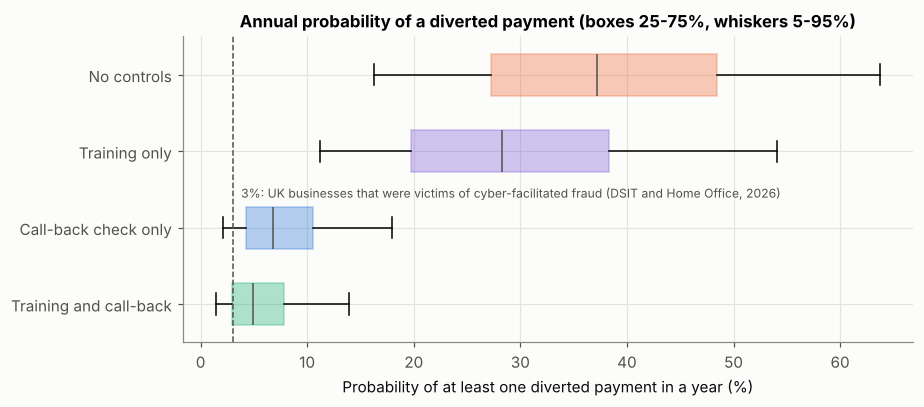

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
names = list(res)
data = [100 * res[k]["p_year"] for k in names]
bp = ax.boxplot(data, orientation="horizontal", whis=(5, 95), showfliers=False, patch_artist=True, widths=0.55)
for patch, col in zip(bp["boxes"], [ORANGE, VIOLET, BLUE, AQUA]):
    patch.set_facecolor(col); patch.set_alpha(0.35); patch.set_edgecolor(col)
for med in bp["medians"]:
    med.set_color(INK)
ax.set_yticks(range(1, 5), names)
ax.invert_yaxis()
ax.axvline(3, color=INK, lw=1, ls="--")
ax.text(3.8, 2.55, "3%: UK businesses that were victims of cyber-facilitated fraud (DSIT and Home Office, 2026)", fontsize=8, color=INK, va="center")
ax.set_xlabel("Probability of at least one diverted payment in a year (%)")
ax.set_title("Annual probability of a diverted payment (boxes 25-75%, whiskers 5-95%)")
fig.tight_layout()
fig.savefig("figures/u8_controls.png", dpi=150)

The call-back check, a procedural control at the last step of the chain, cuts the median annual probability from about 37% to about 7%. Training alone moves it far less, and its effect is uncertain because the multiplier can be close to 1. The two together give the lowest figure, but most of the benefit comes from the call-back. Because all options share the same random numbers, these differences are not sampling noise, and the options can be compared input set by input set.

In [7]:
cb, tr = res["Call-back check only"]["p_year"], res["Training only"]["p_year"]
print(f"Input sets in which the call-back check beats training alone: {np.mean(cb < tr):.1%}")
print(f"Median reduction in annual probability from adding a call-back to no controls: {np.median(1 - cb / res['No controls']['p_year']):.0%}")
print(f"Median reduction from adding training to no controls: {np.median(1 - tr / res['No controls']['p_year']):.0%}")

Input sets in which the call-back check beats training alone: 100.0%
Median reduction in annual probability from adding a call-back to no controls: 81%
Median reduction from adding training to no controls: 23%

## 4. Which input drives the answer?

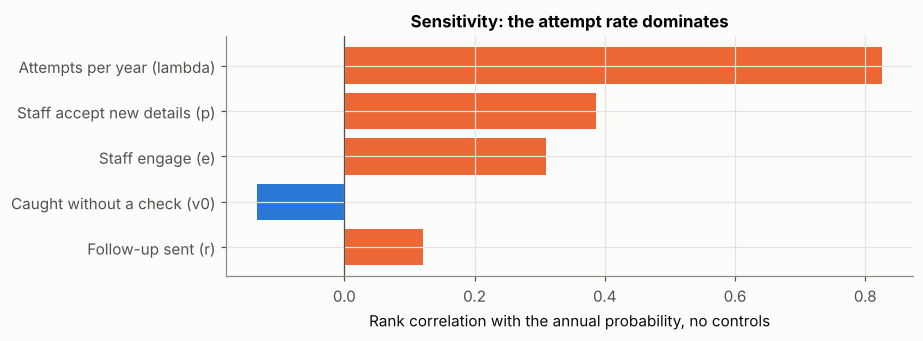

Follow-up sent (r)              0.12
Caught without a check (v0)    -0.13
Staff engage (e)                0.31
Staff accept new details (p)    0.39
Attempts per year (lambda)      0.83

In [8]:
base = res["No controls"]["p_year"]
short = {"lam": "Attempts per year (lambda)", "e": "Staff engage (e)", "r": "Follow-up sent (r)",
         "p": "Staff accept new details (p)", "v0": "Caught without a check (v0)"}
sens = pd.Series({short[k]: stats.spearmanr(d[k], base)[0] for k in short})
sens = sens.reindex(sens.abs().sort_values().index)

fig, ax = plt.subplots(figsize=(8.5, 3.2))
ax.barh(sens.index, sens.values, color=[ORANGE if x > 0 else BLUE for x in sens.values])
ax.axvline(0, color=INK, lw=0.8)
ax.set_xlabel("Rank correlation with the annual probability, no controls")
ax.set_title("Sensitivity: the attempt rate dominates")
fig.tight_layout()
fig.savefig("figures/u8_sensitivity.png", dpi=150)
sens.round(2)

The number of convincing attempts per year (λ) dominates the result, and it is the input I know least about. The behavioural inputs that the persuasion literature studies matter much less here than how often Pampered Pets is targeted.

## 5. A check against national data

The Cyber Security Breaches Survey 2025/26 estimates that 3% of all UK businesses were victims of fraud that resulted from a cyber breach or attack in the previous 12 months (DSIT and Home Office, 2026). The survey covers every kind of business and counts only frauds the business knew about, so it is not a direct test. It is still a warning: with no controls, the model's median is more than ten times higher.

In [9]:
q_med = np.median(res["No controls"]["q"])
lam_needed = -np.log(1 - 0.03) / q_med
print(f"Median per-attempt success with no controls: {q_med:.3f}")
print(f"Attempts per year that would give a 3% annual probability: {lam_needed:.2f} (one every {1/lam_needed:.1f} years)")
print(f"Share of input sets with no controls below 3%: {np.mean(res['No controls']['p_year'] < 0.03):.1%}")
print(f"Share of input sets with a call-back check below 3%: {np.mean(res['Call-back check only']['p_year'] < 0.03):.1%}")

Median per-attempt success with no controls: 0.176
Attempts per year that would give a 3% annual probability: 0.17 (one every 5.8 years)
Share of input sets with no controls below 3%: 0.0%
Share of input sets with a call-back check below 3%: 12.2%

To match the national figure without any controls, a convincing attempt would have to arrive only about once every six years. Either my attempt-rate range is too pessimistic, or the national figure reflects businesses that already check changes of bank details. I cannot tell which from the data I have, and this is why the absolute figures should not be quoted. The ranking of the controls does not depend on λ, since λ multiplies every option equally.

## 6. Updating the attempt rate with evidence

Since λ drives the result, the cheapest improvement is to measure it. Following *Think Bayes* (Downey, 2021), a Bayes table over λ can be updated with a count of impersonation attempts. As a **hypothetical** example, suppose staff log suspicious supplier emails for a year, using a report button of the kind Lain, Kostiainen and Čapkun (2022) found practical, and record one.

In [10]:
grid = np.linspace(0.001, 8, 4000)
lo, mo, hi = inputs.loc["lam", ["min", "mode", "max"]]
prior_expert = stats.triang.pdf(grid, c=(mo - lo) / (hi - lo), loc=lo, scale=hi - lo)
prior_open = stats.gamma.pdf(grid, a=1, scale=3)        # wide prior with mean 3 and no hard floor

k_obs, years = 1, 1.0                                   # HYPOTHETICAL: one attempt logged in one year
like = stats.poisson.pmf(k_obs, grid * years)

def norm(x): return x / np.trapezoid(x, grid)
post_expert, post_open = norm(prior_expert * like), norm(prior_open * like)

q_draws = res["No controls"]["q"]
def p_year_from(density):
    w = density / density.sum()
    lam_s = rng.choice(grid, size=q_draws.size, p=w)
    return 1 - np.exp(-lam_s * q_draws)

rows = {}
for label, dens in [("Expert prior (no data)", norm(prior_expert)), ("Expert prior + 1 attempt in a year", post_expert),
                    ("Open prior + 1 attempt in a year", post_open)]:
    m = np.trapezoid(grid * dens, grid)
    cdf = np.cumsum(dens) / dens.sum()
    py = p_year_from(dens)
    rows[label] = {"lambda mean": m, "lambda 5th pct": grid[np.searchsorted(cdf, 0.05)],
                   "lambda 95th pct": grid[np.searchsorted(cdf, 0.95)],
                   "P(loss in a year), median, no controls": np.median(py)}
bayes = pd.DataFrame(rows).T
bayes.round(3)

,lambda mean,lambda 5th pct,lambda 95th pct,"P(loss in a year), median, no controls"
Expert prior (no data),2.833,1.143,4.952,0.371
Expert prior + 1 attempt in a year,2.201,0.967,3.929,0.302
Open prior + 1 attempt in a year,1.498,0.267,3.553,0.194


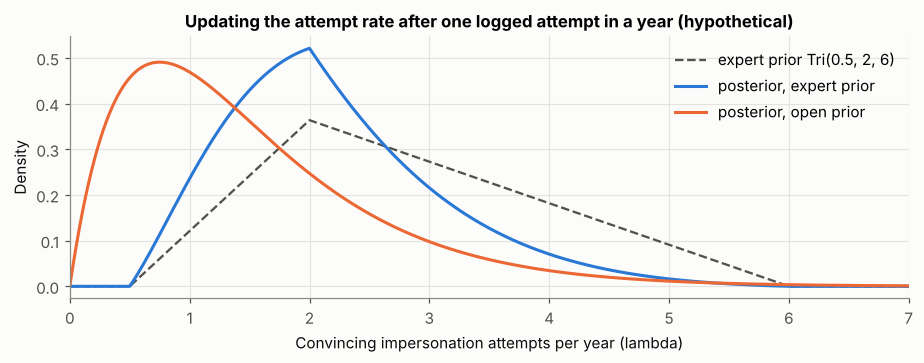

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.plot(grid, norm(prior_expert), color=INK, lw=1.5, ls="--", label="expert prior Tri(0.5, 2, 6)")
ax.plot(grid, post_expert, color=BLUE, label="posterior, expert prior")
ax.plot(grid, post_open, color=ORANGE, label="posterior, open prior")
ax.set_xlim(0, 7)
ax.set_xlabel("Convincing impersonation attempts per year (lambda)")
ax.set_ylabel("Density")
ax.set_title("Updating the attempt rate after one logged attempt in a year (hypothetical)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("figures/u8_lambda_update.png", dpi=150)

One year of logging moves the estimate of λ down from about 2.8 to 2.2 with the expert prior, and to 1.5 with an open prior, which moves further because it has no floor at 0.5. That is the same lesson as the detection-rate prior in Unit 7. The median annual probability with no controls falls from 37% to 30% or 19%. Either way, a simple log gives the model the data it needs most.

## 7. Conclusions for Pampered Pets

1. Of the controls modelled, a rule that **every change of supplier bank details is confirmed by phoning a number already on file** has the largest effect, under every input set, and costs almost nothing. It belongs in phase 1 of the team's Gantt chart alongside the security policy.
2. **Training** should not be the main defence against this threat. Its effect is small in the model and uncertain in the literature (Lain, Kostiainen and Čapkun, 2022).
3. The absolute probabilities rest on the **attempt rate**, which nobody has measured. Logging suspicious supplier emails would replace the largest assumption with data.
4. Compared with the qualitative rating ('medium' likelihood, 'high' risk), the model shows **which step to break** and how much each control is worth, which the matrix cell could not.

### References

Aijaz, M. and Nazir, M. (2024) 'Modelling and analysis of social engineering threats using the attack tree and the Markov model', *International Journal of Information Technology*, 16(2), pp. 1231–1238. https://doi.org/10.1007/s41870-023-01540-z

Bullée, J.-W.H., Montoya, L., Pieters, W., Junger, M. and Hartel, P. (2018) 'On the anatomy of social engineering attacks: a literature-based dissection of successful attacks', *Journal of Investigative Psychology and Offender Profiling*, 15(1), pp. 20–45. https://doi.org/10.1002/jip.1482

Department for Science, Innovation and Technology (DSIT) and Home Office (2026) *Cyber security breaches survey 2025/2026*. Official statistics. https://www.gov.uk/government/statistics/cyber-security-breaches-survey-20252026/cyber-security-breaches-survey-20252026

Downey, A.B. (2021) *Think Bayes: Bayesian statistics in Python*. 2nd edn. Sebastopol, CA: O'Reilly Media. https://allendowney.github.io/ThinkBayes2/

Eckstein, J. and Riedmueller, S.T. (2002) 'YASAI: yet another add-in for teaching elementary Monte Carlo simulation in Excel', *INFORMS Transactions on Education*, 2(2), pp. 12–26. https://doi.org/10.1287/ited.2.2.12

Group 2 (2025) *Pampered Pets risk assessment report*. Unpublished group assignment, Security and Risk Management module. University of Essex Online.

Lain, D., Kostiainen, K. and Čapkun, S. (2022) 'Phishing in organizations: findings from a large-scale and long-term study', in *2022 IEEE Symposium on Security and Privacy (SP)*. San Francisco, CA: IEEE, pp. 842–859. https://doi.org/10.3929/ethz-b-000588856

Stevens, I. (2026) *Quantitative risk assessment and digital resilience strategy for Pampered Pets: executive summary*. Unpublished assignment, Security and Risk Management module. University of Essex Online.